In [2]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

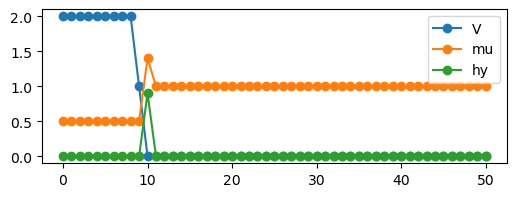

In [8]:
widthS = 10
widthF1 = 1
widthF2 = 40
X, Y = widthS+widthF1+widthF2, 100
lattice = Lattice(X, Y)

t = 1
T = 0.001

muS = 0.5 * t
muF = 1.4 * t
muN = 1.0 * t
mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:widthS+widthF1] = muF
mu[widthS+widthF1:] = muN

h0 = 0.9 * t
hy = np.zeros_like(mu)

hy[widthS:widthS+widthF1] = h0

U=None

V0 = 2 * t
V = V0 * np.ones(lattice.X)
V[widthS:] = 0
V[widthS-1] = V0/2

V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hy, '-o', label='hy')

plt.legend()

In [9]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, g_s=V,
                F_init=[0.01, 0.01, -0.01, -0.01], hy=hy)

In [10]:
bdg_sc(H, atol=1e-6, rtol=1e-3, maxiter=500, verbose=True, temperature=T)

F0:
Absolute error: 0.010471444277818433
Relative error: 10471444277.818432
Average old: 0j
Average: (0.000753550821962958-1.691293774497095e-19j)
F_xplus:
Absolute error: 0.03838548823876216
Relative error: 3016794086.8578024
Average old: (0.002+0j)
Average: (0.0044213349683661935-1.5387363714352476e-18j)
F_xmin:
Absolute error: 0.038385488238762304
Relative error: 3016794086.857992
Average old: (0.002+0j)
Average: (0.0044213349683662065-1.1173924115058515e-18j)
F_yplus:
Absolute error: 0.036974316043684875
Relative error: 6449079431.753228
Average old: (-0.00196078431372549+0j)
Average: (-0.004800182659331016-7.184687294269862e-18j)
F_ymin:
Absolute error: 0.03697431604368494
Relative error: 6449079431.753278
Average old: (-0.00196078431372549+0j)
Average: (-0.0048001826593310265+1.0122061173155456e-17j)
Fuu_xplus:
Absolute error: 0.003951243131123634
Relative error: 3951243131.123634
Average old: 0j
Average: (2.0642620098625261e-19-0.00039124951180101567j)
Fuu_xmin:
Absolute error: 

In [11]:
F, Fuu, Fdd = H.get_correlations()

T/t=0.001, hy/t=0.9


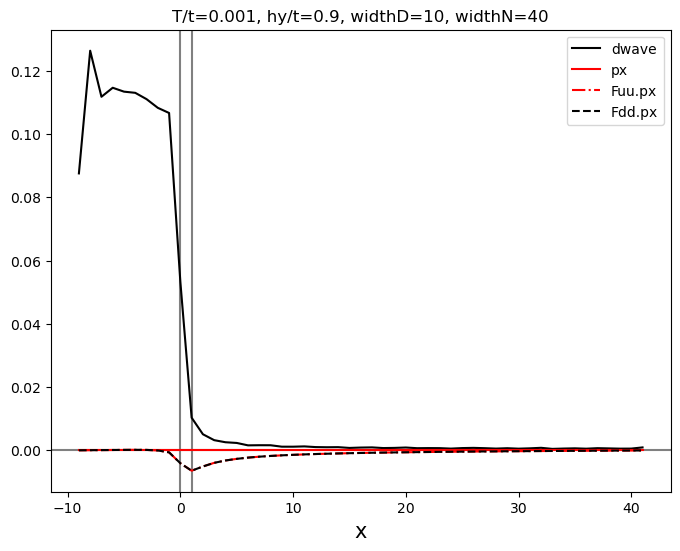

In [12]:
x = np.arange(-widthS, widthF1+widthF2) + 1

fig, axs = plt.subplots(1, 1, figsize=(8, 6))

print(f"T/t={T}, hy/t={h0}")

axs.axhline(0, color='gray')
axs.axvline(0, color='gray')
axs.axvline(widthF1, color='gray')

axs.plot(x, np.abs(F.dwave), label=r"dwave", color='black')
axs.plot(x, np.real(F.px), label=r"px", color='red')
axs.plot(x, np.imag(Fuu.px), "-.", label=r"Fuu.px", color='red')
axs.plot(x, np.imag(Fdd.px), "--", label=r"Fdd.px", color='black')

axs.set_xlabel("x", fontsize=15)
axs.set_title(f"T/t={T}, hy/t={h0}, widthD={widthS}, widthN={widthF2}", )

# axs.set_ylim(None, 0.04)
# axs.set_xlim(-4, 10)
# axs.set_xticks([-4, 0, 5, 10])
plt.legend()
plt.show()

In [13]:
F1, Fuu1, Fdd1 = H.get_correlations()

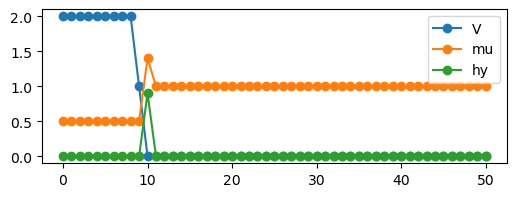

In [14]:
widthS = 10
widthF1 = 1
widthF2 = 40
X, Y = widthS+widthF1+widthF2, 100
lattice = Lattice(X, Y)

t = 1
T = 0.001

muS = 0.5 * t
muF = 1.4 * t
muN = 1.0 * t
mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:widthS+widthF1] = muF
mu[widthS+widthF1:] = muN

h0 = 0.9 * t
hy = np.zeros_like(mu)

hy[widthS:widthS+widthF1] = h0

U=None

V0 = 2 * t
V = V0 * np.ones(lattice.X)
V[widthS:] = 0
V[widthS-1] = V0/2

V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hy, '-o', label='hy')

plt.legend()

In [15]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, g_s=V,
                F_init=[0.1, 0.1, -0.1, -0.1], hx=hy)

In [18]:
bdg_sc(H, atol=1e-6, rtol=1e-3, maxiter=500, verbose=True, temperature=T)

F0:
Absolute error: 9.702765449606579e-08
Relative error: 0.0003436820036304873
Average old: (0.0012214251910778772+0j)
Average: (0.0012214172347780575+0j)
F_xplus:
Absolute error: 3.3189309986002813e-07
Relative error: 6.06635403262727e-05
Average old: (0.021396381589817354+0j)
Average: (0.021396389427629635+0j)
F_xmin:
Absolute error: 3.3189309968714813e-07
Relative error: 6.0663540503940086e-05
Average old: (0.02139638158981736+0j)
Average: (0.02139638942762961+0j)
F_yplus:
Absolute error: 8.130849392553398e-08
Relative error: 4.091584089637036e-06
Average old: (-0.022151679073359822-6.608151508203664e-17j)
Average: (-0.02215167816037334-2.5364746578468156e-17j)
F_ymin:
Absolute error: 8.130849392553398e-08
Relative error: 4.091584089637036e-06
Average old: (-0.022151679073359822+6.608151508203664e-17j)
Average: (-0.02215167816037334+2.5364746578468156e-17j)
Fuu_xplus:
Absolute error: 1.7585806102217928e-08
Relative error: 0.00012963736663489786
Average old: (0.0009720193137725859+0

In [19]:
F, Fuu, Fdd = H.get_correlations()

T/t=0.001, hy/t=0.9


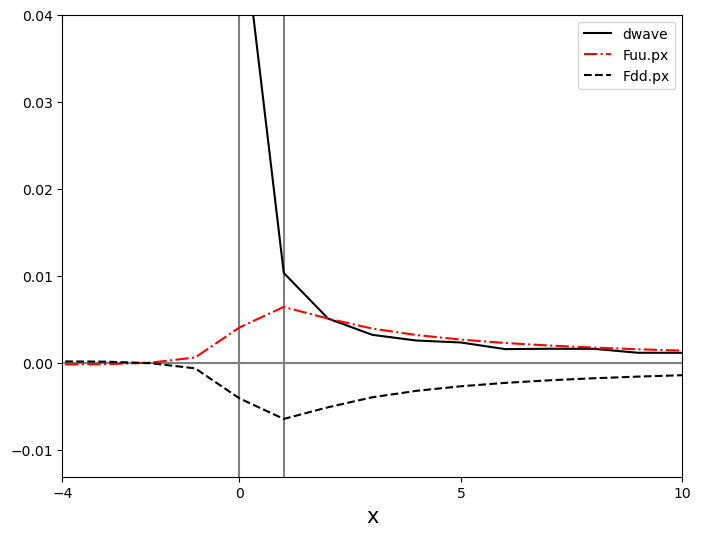

In [20]:
x = np.arange(-widthS, widthF1+widthF2) + 1

fig, axs = plt.subplots(1, 1, figsize=(8, 6))

print(f"T/t={T}, hy/t={h0}")

axs.axhline(0, color='gray')
axs.axvline(0, color='gray')
axs.axvline(widthF1, color='gray')

axs.plot(x, np.abs(F.dwave), label=r"dwave", color='black')
# axs.plot(x, np.real(F.px), label=r"px", color='red')
axs.plot(x, np.real(Fuu.px), "-.", label=r"Fuu.px", color='red')
axs.plot(x, np.real(Fdd.px), "--", label=r"Fdd.px", color='black')

axs.set_xlabel("x", fontsize=15)

axs.set_ylim(None, 0.04)
axs.set_xlim(-4, 10)
axs.set_xticks([-4, 0, 5, 10])
plt.legend()
plt.show()

In [21]:
F2, Fuu2, Fdd2 = H.get_correlations()

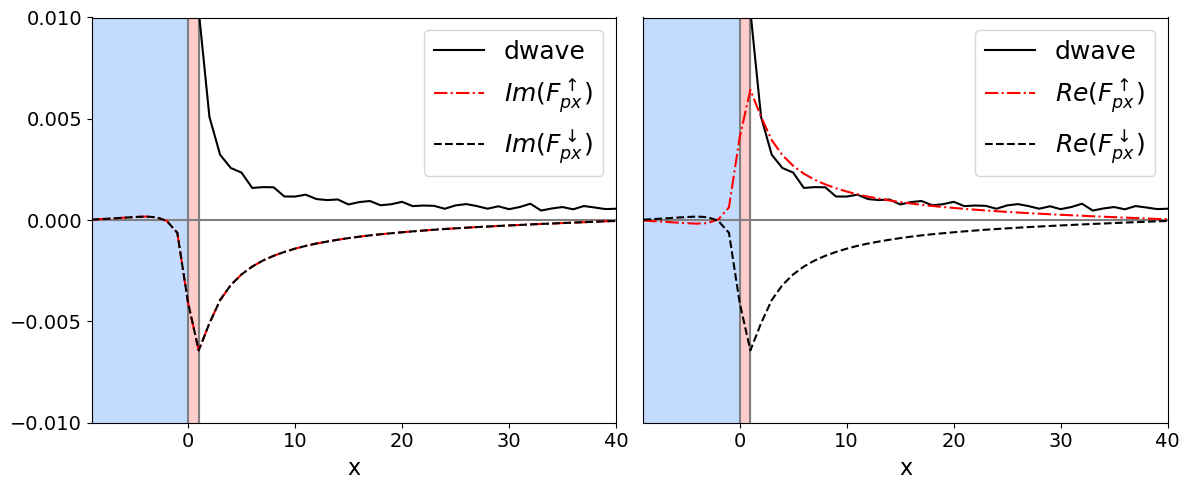

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].axhline(0, color='gray')
axs[0].axvline(0, color='gray')
axs[0].axvline(widthF1, color='gray')

axs[0].plot(x, np.abs(F1.dwave), label=r"dwave", color='black')
axs[0].plot(x, np.imag(Fuu1.px), "-.", label=r"$Im(F^{\uparrow}_{px})$", color='red')
axs[0].plot(x, np.imag(Fdd1.px), "--", label=r"$Im(F^{\downarrow}_{px})$", color='black')

axs[0].set_xlabel("x", fontsize=16)
axs[0].set_ylim(-0.01, 0.01)
axs[0].set_xlim(-9, 40)
axs[0].tick_params(axis='x', labelsize=14)
axs[0].tick_params(axis='y', labelsize=14)
axs[0].legend(fontsize=18)
axs[0].axvspan(0, 1, color='#FFCCCC', alpha=1)
axs[0].axvspan(-10, 0, color='#89B9FF', alpha=0.5)
axs[0].set_yticks([-0.01, -0.005, 0, 0.005, 0.01])


axs[1].axhline(0, color='gray')
axs[1].axvline(0, color='gray')
axs[1].axvline(widthF1, color='gray')

axs[1].plot(x, np.abs(F2.dwave), label=r"dwave", color='black')
axs[1].plot(x, np.real(Fuu2.px), "-.", label=r"$Re(F^{\uparrow}_{px})$", color='red')
axs[1].plot(x, np.real(Fdd2.px), "--", label=r"$Re(F^{\downarrow}_{px})$", color='black')

axs[1].set_xlabel("x", fontsize=16)
axs[1].set_ylim(-0.01, 0.01)
axs[1].set_xlim(-9, 40)
axs[1].set_yticks([])
axs[1].tick_params(axis='x', labelsize=14)
axs[1].legend(fontsize=18)
axs[1].axvspan(0, 1, color='#FFCCCC', alpha=1)
axs[1].axvspan(-10, 0, color='#89B9FF', alpha=0.5)


plt.tight_layout()
plt.savefig("../figures/DFN_small.svg", bbox_inches='tight')